## Usfull libraries:


In [70]:
import camb
from camb import model, initialpower
from classy import Class
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord
from scipy.integrate import quad
from scipy.interpolate import interp1d
from scipy.integrate import simpson

## cosmological parameters:

In [53]:
OmegaM= 0.3151
OmegaLambda = 1.0-OmegaM
H0 = 67.27

## 1.get the linear PS from CAMB:

sigma8_fid =  0.811750044674705


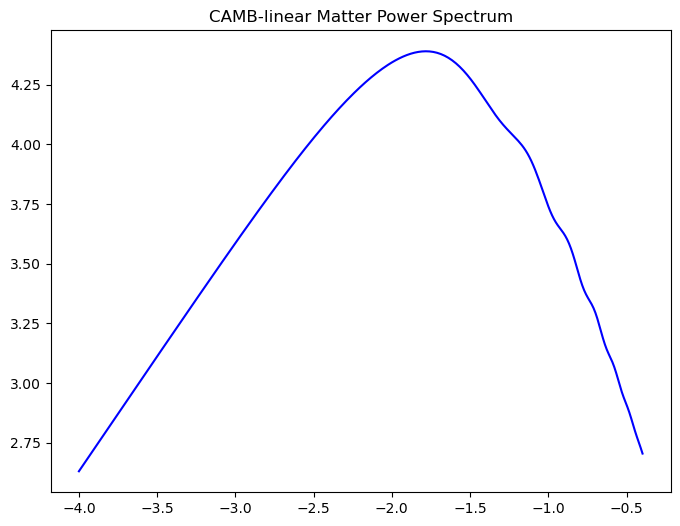

In [54]:
pars = camb.CAMBparams()
pars.set_cosmology(H0,ombh2=0.022, omch2=0.1198)
pars.set_dark_energy() #re-set defaults
pars.InitPower.set_params(As=2.114940245149156e-09,ns=0.9645)
pars.set_matter_power(redshifts=[0.], kmax=0.4)
pars.NonLinear = model.NonLinear_none
results = camb.get_results(pars)
khs, z, pks = results.get_matter_power_spectrum(minkh=1e-4, maxkh=0.4, npoints = 300) 
Sig8_fid = results.get_sigma8()[0]
Pk_linear=pks[0,:]
k_linear=khs
print( 'sigma8_fid = ',Sig8_fid)

plt.figure(4,figsize=(8,6))
plt.plot(np.log10(k_linear),np.log10(Pk_linear),color='b')
plt.title('CAMB-linear Matter Power Spectrum')
plt.show()

outfile = open('/renoir/fromenti/Documents/codes_Bulk_flow/results/figures/power_spectrum_camb.dat', 'w')
outfile.write(" %18d\n"% (len(k_linear)))
for i in range(len(k_linear)):  
    outfile.write("%12.6lf  %12.6lf  \n"% (k_linear[i],Pk_linear[i]))
outfile.close()

## 2. get the coordinates of r from the (Ra,dec) coordinates from data:

In [55]:

data_mardec = '/datadec/desi/pv/combinedpv/Y1/PV_clustering_data_v5_v13.fits'
data_pc = '/renoir/fromenti/Documents/data_DESI/combinedpv/Y1/PV_clustering_data_v5_v13.fits'
with fits.open(data_pc) as hfile:
    infile = hfile[1].data

ra    = infile['RA']
dec   = infile['DEC']
zv    = infile['Z']
logd  = infile['LOGDIST']
elogd = infile['LOGDIST_ERR']

dist = 10**logd # en Mpc ou Mpc/h
err_dist = 10**elogd # error on the logdistance

x = np.cos(np.radians(dec)) * np.cos(np.radians(ra))
y = np.cos(np.radians(dec)) * np.sin(np.radians(ra))
z = np.sin(np.radians(dec))
r = (x,y,z) # the coordinates of r in cartesian coordinates
r = np.vstack((x, y, z)).T  # shape (N, 3)
print('the coordinates of r for the first galaxy in the data file, in cartesian coordinates',r[0]) 

# the norme of r:
r_hat = r / np.linalg.norm(r)

the coordinates of r for the first galaxy in the data file, in cartesian coordinates [-0.94086305 -0.33744514  0.03012459]


## 3. get fnm function :

In [56]:
def f_nm(k,rn,rm):
    
    # the norme of r:
    r_hat_n = rn / np.linalg.norm(rn)
    r_hat_m = rm / np.linalg.norm(rm)
    d_nm = np.linalg.norm(rn - rm)
    cos_alpha = np.dot(rn, rm) / (np.linalg.norm(rn)*np.linalg.norm(rm))
    cos_alpha = np.clip(cos_alpha, -1, 1)
    alfa_nm = np.arccos(cos_alpha)
    #alfa_nm = np.arccos(np.dot(rn, rm) / (np.linalg.norm(rn)*np.linalg.norm(rm)))
    
    return 1/3*(special.spherical_jn(0,k*d_nm) - 
                2*special.spherical_jn(2,k*d_nm))* np.dot(r_hat_n, r_hat_m)*special.spherical_jn(2,k*d_nm)* np.dot(rn,rm) *(np.sin(alfa_nm)**2) / d_nm**2


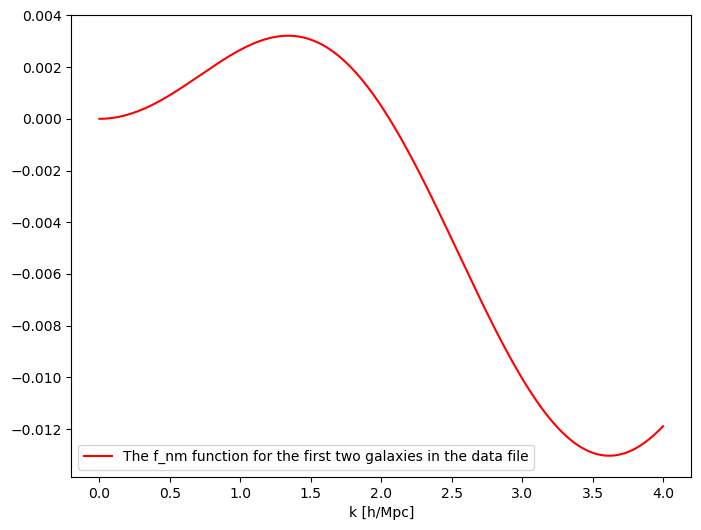

In [84]:
plt.figure(4,figsize=(8,6))
k_linear = np.linspace(0,4,80628)
plt.plot(k_linear,f_nm(k_linear,r[0],r[1]),color='r',label='The f_nm function for the first two galaxies in the data file')
plt.legend(fontsize=10)
plt.xlabel('k [h/Mpc]')
plt.show()

## 4.get the window function:

In [ ]:
# to extract the weights of each galaxies:
# But we have one weight for one galaxy and for one component Bx,By;Bz,Qxx,Qxy,... 
hdul = fits.open('/renoir/fromenti/Documents/data_DESI/combinedpv/Y1/PV_clustering_data_v5_v13.fits')
print(hdul[1].columns.names) 
weights = hdul[1].data['WEIGHT'] # the size of weights is the number of galaxies in the data file
print('the weights of the first galaxie :', weights[0])

['TARGETID', 'SGA_ID', 'FP_FLAG', 'RA', 'DEC', 'Z', 'ZCMB', 'WEIGHT', 'NPV', 'NDENS', 'MU', 'MU_ERR', 'LOGDIST', 'LOGDIST_ERR', 'PV', 'PV_ERR']
the weights of the first galaxie : 0.964532575634106


In [ ]:
def window_function2(k,N):
    
    w = 0
    for n in range (0,N):
        for m in range (0,N):
            if n != m: 
                w += weights[n]*weights[m]*f_nm(k,r[n],r[m])

    return w

In [59]:
print('the window function for the first 10 galaxies in the data file, for k=0.1 h/Mpc is',window_function2(0.1,10))

the window function for the first 10 galaxies in the data file, for k=0.1 h/Mpc is 0.001958717909663401


##  5. plot of the window function in function :

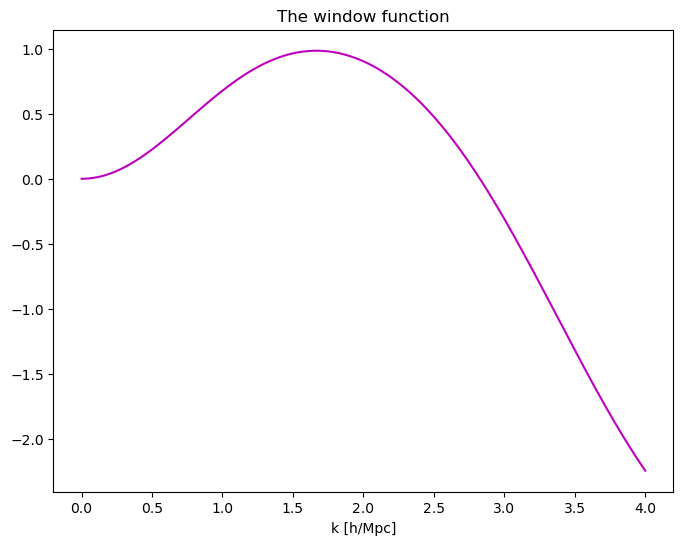

In [86]:
k = np.linspace(0.001,4,80628)
plt.figure(4,figsize=(8,6))
plt.plot(k,window_function2(k_linear,N=20),color='m')
plt.title('The window function')
plt.xlabel('k [h/Mpc]')
plt.show()

In [76]:
# integral of the window function:

def W_scalar(k):
    return window_function2(k, N=100)

result, error = quad(W_scalar, 0.001, 0.4)

print("Integral =", result)
print("Error estimate =", error)

Integral = 0.5073930661110715
Error estimate = 5.633194645316658e-15


## R_pq the CRMS (cosmic root mean square) variation : 

In [85]:
# integrale avec simpson car on a des tableaux c'est plus facile :

W = window_function2(khs, N=20)
R = W * Pk_linear * OmegaM * H0**2 / (2*np.pi**2)

result = simpson(R, khs)

print("Integral =", result)

Integral = 1822.661415440933


In [ ]:
# intergrate with the quad method but it is a little more slow :

Pk_interp = interp1d(khs, Pk_linear, kind='linear', bounds_error=False, fill_value=0)

def R_scalar(khs):
    return window_function2(khs,N=20) * Pk_interp(khs) * OmegaM * H0**2 / (2*np.pi**2)

result, error = quad(R_scalar, 0.001, 0.4 )

print("Integral =", result)
print("Error estimate =", error)

Integral = 1823.1742977742267
Error estimate = 0.0808750887563292


/tmp/ipykernel_702807/417860153.py:6: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, error = quad(R_scalar, 0.001, 0.4 )
